In [1]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import h5py
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
from numpy.linalg import lstsq
from scipy.optimize import nnls  # non-negative least squares
from sklearn.linear_model import Lasso
from tqdm.auto import tqdm  # ✅ Recommended for notebooks
import math
import importlib
from scipy.interpolate import interp1d
from interactive_notebooks.n21_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *
from interactive_notebooks.n23_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n23_attachment'])
from interactive_notebooks.n23_attachment import *
from interactive_notebooks.n24_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n24_attachment'])
from interactive_notebooks.n24_attachment import *

In [2]:
slice_index = 32,72
nz = slice_index[1] - slice_index[0]
spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
max_blur = 6
num_materials = 16
num_blur = 12

In [3]:
start, stop = slice_index
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset_abs = f["absorption"]
    DA_2 = dataset_abs[:,130:230]

absorption = DA_2[start:stop]
mask = absorption>0.002

Keys: ['absorption']


In [4]:
coef_xray, coef_neutron, labels = get_attenuation_coefficients()
def find_first_indices(A, B):
    return [B.index(a) if a in B else None for a in A]


spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
indices = np.array(find_first_indices(keys_simple, labels))
coef_neutron = coef_neutron[indices]
coef_xray = coef_xray[indices]

In [5]:
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
theta_reg = False
threshold = 3.5
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=slice_index)
print(f"Number of files: {len(all_files)}")
extra_filename = '/dtu-compute/msaca/sliceA_diffraction/abs_volume/XA_and_NA_x_5.h5'
dataset = ThresholdedH5Dataset(index_list, threshold=threshold,
                                slice_index = slice_index,
                                N_splits = 1,
                                split = [1,1,1],
                                extra_filename=extra_filename,
                                all_files = all_files)
spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
stds = np.linspace(0.1,max_blur,num_blur)
spectra = add_convolved_columns(spectra, stds)
N_2theta = 667
method = 'GPU_Lasso'
alpha = 0.005
num_background = 5
background_filter_sigma = None
box = None
j_global = 40
k_global = 100

A, keys = resample_all_blurs(spectra, start_col=2, target_x=np.linspace(0.01, 18.408, N_2theta))
if background_filter_sigma is None:
    A = add_fourier_background_basis(A, np.linspace(0,18.4,N_2theta), num_frequencies=num_background)

if box is None:
    box = [0, 100, 0, 362]  # default full region
ny = box[1] - box[0]
nx = box[3] - box[2]

att_xray = np.zeros(A.shape[1])
att_neutron = np.zeros(A.shape[1])

att_xray[:num_blur*num_materials] = np.repeat(coef_xray,num_blur)
att_neutron[:num_blur*num_materials] = np.repeat(coef_neutron,num_blur)
A_ = np.vstack([A,100*att_xray,100*att_neutron])

w = np.ones(N_2theta+2)
w[:100] = 0
w[-2] = 100
w[-1] = 10

Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0403.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0405.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0407.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0409.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0411.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0413.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0415.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0417.h5 with shape (667, 100, 362)
Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0419.h5 with shape (667, 100, 362)
Processing

In [6]:
materials = fit_all_pixels_spatial(dataset, A_, alpha=10, mu = 10000, box=box,background_filter_sigma = None,
     w=w, N_iter=400, learning_rate=1e-3, eps = 1e-8, regularization = 'spatial_tv')
     
if background_filter_sigma is None:
    materials_ = materials[:-(2*num_background)]

materials_4d = materials_.reshape(num_materials, num_blur, ny, nx,nz)
materials_summed1 = materials_4d.sum(axis=1)

Iteration 0, Loss: 263.7078, Data Fit: 263.5058, Regularization: 0.2020
Iteration 100, Loss: 14.3887, Data Fit: 13.2990, Regularization: 1.0897
Iteration 200, Loss: 14.1404, Data Fit: 13.0039, Regularization: 1.1365
Iteration 300, Loss: 14.0662, Data Fit: 12.9222, Regularization: 1.1440


(16, 100, 362, 3)
['Chlorapatite', 'Diopside', 'Hematite', 'Ferrosilite', 'Magnetite', 'Pyrite', 'Ilmenite', 'Orthoclase', 'Enstatite', 'Forsterite', 'Spinel', 'Albite', 'Rutile', 'Baddeleyite', 'Zircon', 'Wüstite']
Chlorapatite


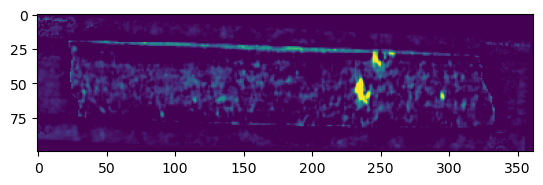

Diopside


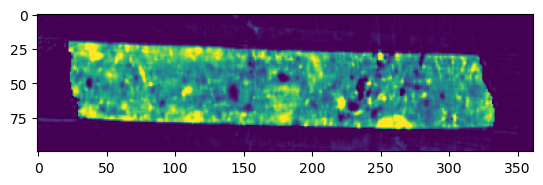

Hematite


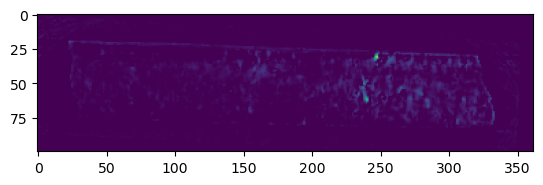

Ferrosilite


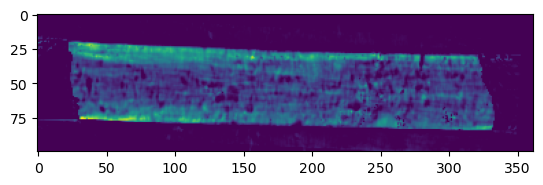

Magnetite


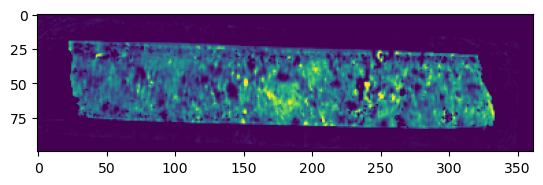

Pyrite


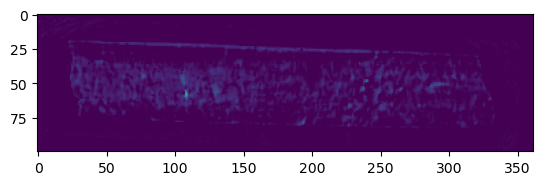

Ilmenite


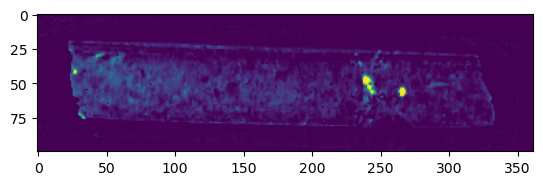

Orthoclase


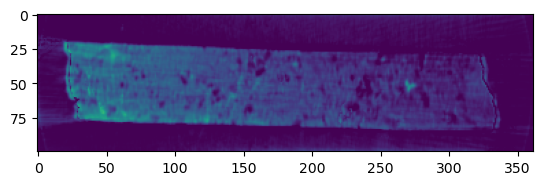

Enstatite


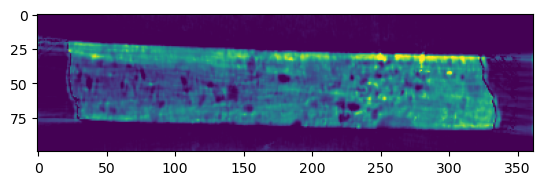

Forsterite


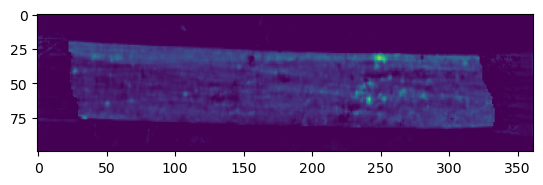

[ 2.425541   13.590542    0.5048633   6.1192365   8.574516    0.7944493
  2.1857307   5.459878    9.335296    3.2514083   0.840392   11.69224
  0.73648214  1.0779067   0.73587     0.61859274]


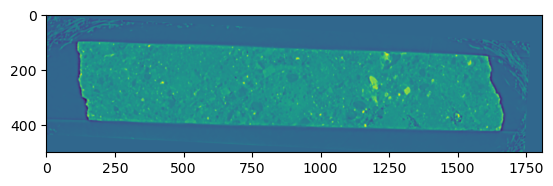

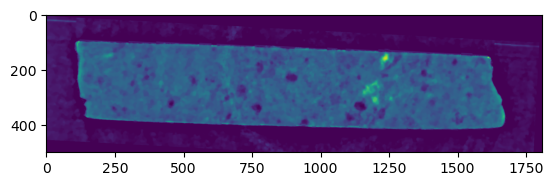

In [131]:
print(np.shape(materials_summed1))
print(keys_simple)
for i in range(10):
    print(keys_simple[i])
    plt.imshow(materials_summed1[i,:,:,0])
    plt.clim([0,0.05])
    plt.show()
print(np.mean(materials_summed1,axis=(1,2,3))*1000)
plt.imshow(dataset.extra_data_XA[7])
plt.show()
plt.imshow(dataset.extra_data_NA[7])
plt.show()

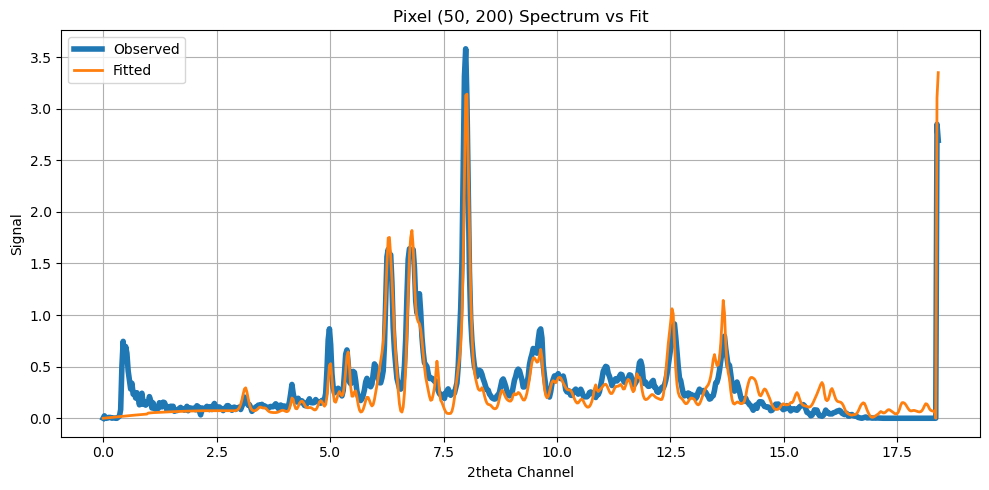

In [107]:
j_global = 50
k_global = 200

materials1 = materials[:,:,:,0]
if display:
    plot_pixel_fit(j_global=j_global, k_global=k_global, dataset=dataset, materials=materials1,
            A=A_, box=box,filename=all_files[0], background_filter_sigma=background_filter_sigma)
materials1_mean = materials1[:-2*num_background].reshape(num_materials, num_blur, *materials1.shape[1:]).mean(axis=1)

In [ ]:
np.save('/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions/arr5.npy',materials_summed1)

In [6]:

full_data = np.empty((num_materials,ny, nx , 71))

full_data[:,:,:,:35] = np.load('/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions/arr3.npy')[:,:,:,:35]
full_data[:,:,:,-36:] = np.load('/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions/arr4.npy')[:,:,:,-36:]
dictionary = {key: full_data[i].astype(np.float32) for i, key in enumerate(keys_simple)}

In [9]:
d = dictionary
               #'/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions'
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions/material_decomp2.h5', 'w') as f:
    for key, value in d.items():
        f.create_dataset(key, data=value)

In [11]:
kernel = make_kernel('gaussian', size=3, sigma=1.0)
#kernel = make_kernel('distance_inverse', size=5)
materials = fit_all_pixels_spatial(dataset, A, alpha=10, mu = 10000, box=box,background_filter_sigma = None,
     w=w, N_iter=300, learning_rate=1e-3, eps = 1e-8, regularization = 'gaussian_tv', kernel = kernel)
if background_filter_sigma is None:
    materials_ = materials[:-(2*num_background)]

materials_4d = materials_.reshape(num_materials, num_blur,ny, nx, nz)
materials_summed2 = materials_4d.sum(axis=1)

KeyboardInterrupt: 

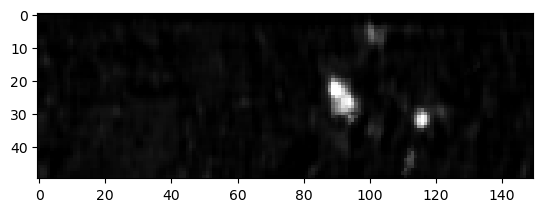

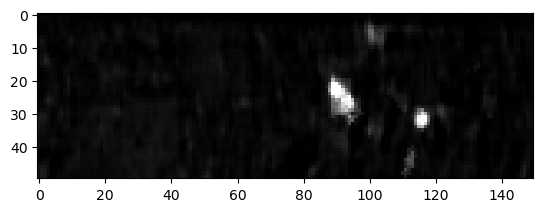

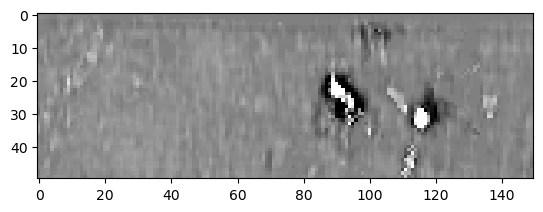

In [ ]:
N = 6
boxx = [25, 75, 150, 300]  # default full region
plt.imshow(materials_summed1[N][boxx[0]:boxx[1], boxx[2]:boxx[3],0], cmap='gray', vmin=0, vmax=0.2)
plt.show()
plt.imshow(materials_summed2[N][boxx[0]:boxx[1], boxx[2]:boxx[3],0], cmap='gray', vmin=0, vmax=0.2)
plt.show()
plt.imshow(materials_summed2[N][boxx[0]:boxx[1], boxx[2]:boxx[3],0]-materials_summed1[N][boxx[0]:boxx[1], boxx[2]:boxx[3],0], cmap='gray', vmin=-0.01, vmax=0.01)
plt.show()